# 01 — Analyse exploratoire des données (EDA) : Raffinage CDU & Vapocraqueur

## Contexte métier

Cette étude porte sur une **raffinerie de 200 000 barils/jour**. L'unité de distillation
atmosphérique (**CDU**, *Crude Distillation Unit*) et le **vapocraqueur** sont les deux
goulets d'étranglement du site. Le projet vise à construire un **jumeau numérique** piloté
par des réseaux de neurones profonds (PyTorch) pour répondre à 5 objectifs chiffrés :

| # | Objectif | Critère de succès | Solution DL |
|---|----------|--------------------|--------------|
| 1 | Prédire les rendements des coupes (naphta, kérosène, gazole, résidu) | MAPE < 5 % par coupe | LSTM/GRU/TCN/Transformer (comparés) |
| 2 | Détecter le fouling (encrassement) | Détection > 24 h avant nettoyage | Autoencodeurs + résidus LSTM |
| 3 | Optimiser la température du four (COT) | Gain énergétique > 5 % | Surrogate NN + gradient sur entrées |
| 4 | Prédire la qualité des produits (soft sensor labo) | Corrélation > 0.9 | GRU multi-sorties |
| 5 | Système d'alerte temps réel | Latence < 1 min | Pipeline d'inférence + moteur d'alertes |

Toutes les données utilisées sont **100 % synthétiques**, générées par `src/data_generator.py`
à partir de bilans matière/énergie simplifiés (aucune source externe). Ce notebook explore
les 4 tables générées : `cdu_data`, `energy_data`, `cracker_data`, `lab_data`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src.config_loader import load_config, resolve_path

cfg = load_config("../config.yaml")
FIG_DIR = resolve_path(cfg["paths"]["figures_dir"])
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
sns.set_palette(["#0891b2", "#f59e0b", "#10b981", "#ef4444", "#7c3aed"])

RAW_DIR = resolve_path(cfg["paths"]["raw_dir"])
cdu = pd.read_csv(RAW_DIR / "cdu_data.csv", parse_dates=["timestamp"]).set_index("timestamp")
energy = pd.read_csv(RAW_DIR / "energy_data.csv", parse_dates=["timestamp"]).set_index("timestamp")
cracker = pd.read_csv(RAW_DIR / "cracker_data.csv", parse_dates=["timestamp"]).set_index("timestamp")
lab = pd.read_csv(RAW_DIR / "lab_data.csv", parse_dates=["sample_time", "result_time"])

print("cdu_data     :", cdu.shape)
print("energy_data  :", energy.shape)
print("cracker_data :", cracker.shape)
print("lab_data     :", lab.shape)
cdu.head()

cdu_data     : (17544, 12)
energy_data  : (17544, 9)
cracker_data : (17544, 10)
lab_data     : (2193, 7)


,feed_rate,crude_type,crude_api,furnace_cot,column_top_temp,column_top_pressure,reflux_ratio,stripping_steam,naphtha_yield,kerosene_yield,gasoil_yield,residue_yield
timestamp,,,,,,,,,,,,
2024-01-01 00:00:00,1325.000000,lourd,27.060222,365.557040,119.963389,1.800000,2.400000,3.200000,0.149335,0.169771,0.299098,0.381796
2024-01-01 01:00:00,1317.980107,lourd,26.834676,365.256224,120.108516,1.804623,2.415820,3.139590,0.149582,0.168988,0.299157,0.382273
2024-01-01 02:00:00,1318.696508,lourd,26.968617,365.731143,120.554378,1.824491,2.356303,3.059622,0.149614,0.171615,0.301552,0.377219
2024-01-01 03:00:00,1319.412909,lourd,26.894163,365.232279,119.267033,1.823128,2.456872,3.242692,0.150327,0.166888,0.298508,0.384276
2024-01-01 04:00:00,1320.129311,lourd,27.138498,364.996181,118.405221,1.794468,2.570034,3.303456,0.152567,0.165455,0.296687,0.385291


## 1. Statistiques descriptives

In [2]:
print("=== CDU ===")
display(cdu.describe().T)
print("\n=== Énergie / Fouling (fouling_resistance = vérité terrain cachée) ===")
display(energy.describe().T)
print("\n=== Vapocraqueur ===")
display(cracker.describe().T)
print("\n=== Laboratoire ===")
display(lab.describe().T)

=== CDU ===


,count,mean,std,min,25%,50%,75%,max
feed_rate,17369.0,1324.792619,25.924471,1149.541284,1308.373412,1324.192781,1340.994610,1478.884726
crude_api,17369.0,30.373159,3.055476,14.835236,27.047550,30.943236,33.886321,46.203845
furnace_cot,17369.0,365.693091,1.642994,355.281294,364.641969,365.679159,366.760927,374.076091
column_top_temp,17369.0,118.925847,2.177602,105.301336,117.429401,118.896954,120.352388,131.141371
column_top_pressure,17369.0,1.801187,0.056814,1.452454,1.763477,1.799834,1.838642,2.122076
reflux_ratio,17369.0,2.401526,0.195343,1.232277,2.269128,2.398058,2.530545,3.667910
stripping_steam,17369.0,3.194153,0.211452,2.003934,3.054253,3.192897,3.333975,4.390780
naphtha_yield,17369.0,0.211290,0.056945,-0.083881,0.151527,0.217310,0.275055,0.516101
kerosene_yield,17369.0,0.194268,0.022577,0.069270,0.171736,0.197328,0.215839,0.310519
gasoil_yield,17369.0,0.302397,0.008012,0.255770,0.297028,0.302278,0.307681,0.360832



=== Énergie / Fouling (fouling_resistance = vérité terrain cachée) ===


,count,mean,std,min,25%,50%,75%,max
fouling_resistance,17544.0,0.002584,0.001332,0.000000,0.001439,0.002788,0.003774,0.004647
preheat_outlet_temp,17544.0,236.727408,4.380113,227.860095,232.973933,236.089880,240.392360,247.855344
fuel_gas_flow,17544.0,4.964858,0.129155,4.225167,4.875430,4.969006,5.055260,5.576144
furnace_duty,17544.0,44.888465,1.743974,36.821018,43.564507,45.036475,46.248196,51.544640
specific_energy,17544.0,1.720994,0.122607,1.443248,1.616906,1.739818,1.828984,1.948707
co2_emissions,17544.0,9.067470,0.352283,7.437846,8.800030,9.097368,9.342136,10.412017
cleaning_needed_within_24h,17544.0,0.005472,0.073772,0.000000,0.000000,0.000000,0.000000,1.000000
cleaning_needed_within_48h,17544.0,0.010944,0.104042,0.000000,0.000000,0.000000,0.000000,1.000000
is_cleaning_event,17544.0,0.000228,0.015098,0.000000,0.000000,0.000000,0.000000,1.000000



=== Vapocraqueur ===


,count,mean,std,min,25%,50%,75%,max
naphtha_feed,17544.0,209.812056,7.918874,179.420631,204.441153,209.816265,215.145827,237.886106
coil_outlet_temp,17544.0,840.172824,6.387612,820.000000,835.857951,840.221528,844.523386,860.000000
steam_to_oil_ratio,17544.0,0.449450,0.046133,0.280492,0.418522,0.448278,0.479460,0.615700
residence_time,17544.0,0.349505,0.022910,0.266601,0.334285,0.349640,0.364575,0.430525
ethylene_yield,17544.0,0.255998,0.042689,-0.009894,0.236548,0.265194,0.286043,0.336666
propylene_yield,17544.0,0.152546,0.024074,-0.005556,0.146121,0.161515,0.167694,0.180941
c4_yield,17544.0,0.095752,0.008254,0.065363,0.090165,0.095737,0.101299,0.126497
pygas_yield,17544.0,0.152813,0.009524,0.116565,0.146294,0.152847,0.159293,0.188340
coke_thickness,17544.0,0.412026,0.168147,0.000000,0.296703,0.462978,0.552525,0.649326
tube_metal_temp,17544.0,1030.371099,6.330243,1008.165025,1026.140610,1030.687365,1034.795974,1050.665698



=== Laboratoire ===


,count,mean,min,25%,50%,75%,max,std
sample_time,2193,2024-12-31 08:00:00,2024-01-01 00:00:00,2024-07-01 16:00:00,2024-12-31 08:00:00,2025-07-02 00:00:00,2025-12-31 16:00:00,NaN
result_time,2193,2024-12-31 12:00:00,2024-01-01 04:00:00,2024-07-01 20:00:00,2024-12-31 12:00:00,2025-07-02 04:00:00,2025-12-31 20:00:00,NaN
naphtha_final_boiling_point,2168.0,165.414214,155.0888,163.263542,165.417408,167.607959,175.082787,3.173567
kerosene_flash_point,2148.0,45.181966,39.498544,44.113518,45.156445,46.277446,50.004012,1.585696
gasoil_cetane_index,2146.0,49.631906,42.944428,48.186372,49.652316,51.062772,57.041219,1.878913
residue_viscosity,2146.0,384.815756,301.241663,367.866413,385.353038,401.633558,470.157077,20.765568
sulfur_content,2193.0,1.18987,0.252024,0.310384,0.91769,2.067596,2.527128,0.789487


**Conclusion (1. Statistiques descriptives)** — Les ordres de grandeur sont cohérents avec
la physique attendue : COT four entre 355 et 375 °C, rendements sommant à ~1, résistance
d'encrassement bornée sous 0.005 m²K/W. Les échantillons labo (`lab_data`) sont ~8× moins
nombreux que les tables horaires (échantillonnage toutes les 8 h), comme spécifié.

## 2. Valeurs manquantes

feed_rate              1.0
crude_api              1.0
furnace_cot            1.0
column_top_temp        1.0
naphtha_yield          1.0
column_top_pressure    1.0
reflux_ratio           1.0
stripping_steam        1.0
gasoil_yield           1.0
kerosene_yield         1.0
residue_yield          1.0
crude_type             0.0
dtype: float64


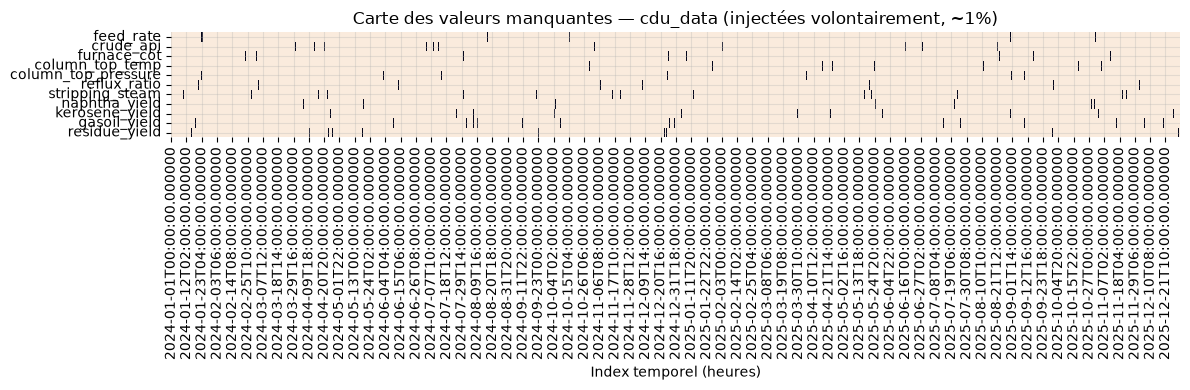

In [3]:
missing_pct = cdu.isna().mean().sort_values(ascending=False) * 100
print(missing_pct.round(2))

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(cdu.drop(columns=["crude_type"]).isna().T, cbar=False, cmap="rocket_r", ax=ax)
ax.set_title("Carte des valeurs manquantes — cdu_data (injectées volontairement, ~1%)")
ax.set_xlabel("Index temporel (heures)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_missing_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (2. Valeurs manquantes)** — Le taux de valeurs manquantes (~1 % par capteur,
répartition aléatoire dans le temps) confirme l'injection volontaire décrite dans le générateur.
Ces trous seront traités par interpolation temporelle dans le notebook 02.

## 3. Outliers (IQR et z-score)

,n_outliers_IQR(k=3),n_outliers_zscore(>4)
feed_rate,32,54
crude_api,0,20
furnace_cot,17,27
column_top_temp,14,29
column_top_pressure,17,27
reflux_ratio,15,28
stripping_steam,12,24
naphtha_yield,0,21
kerosene_yield,0,20
gasoil_yield,14,23


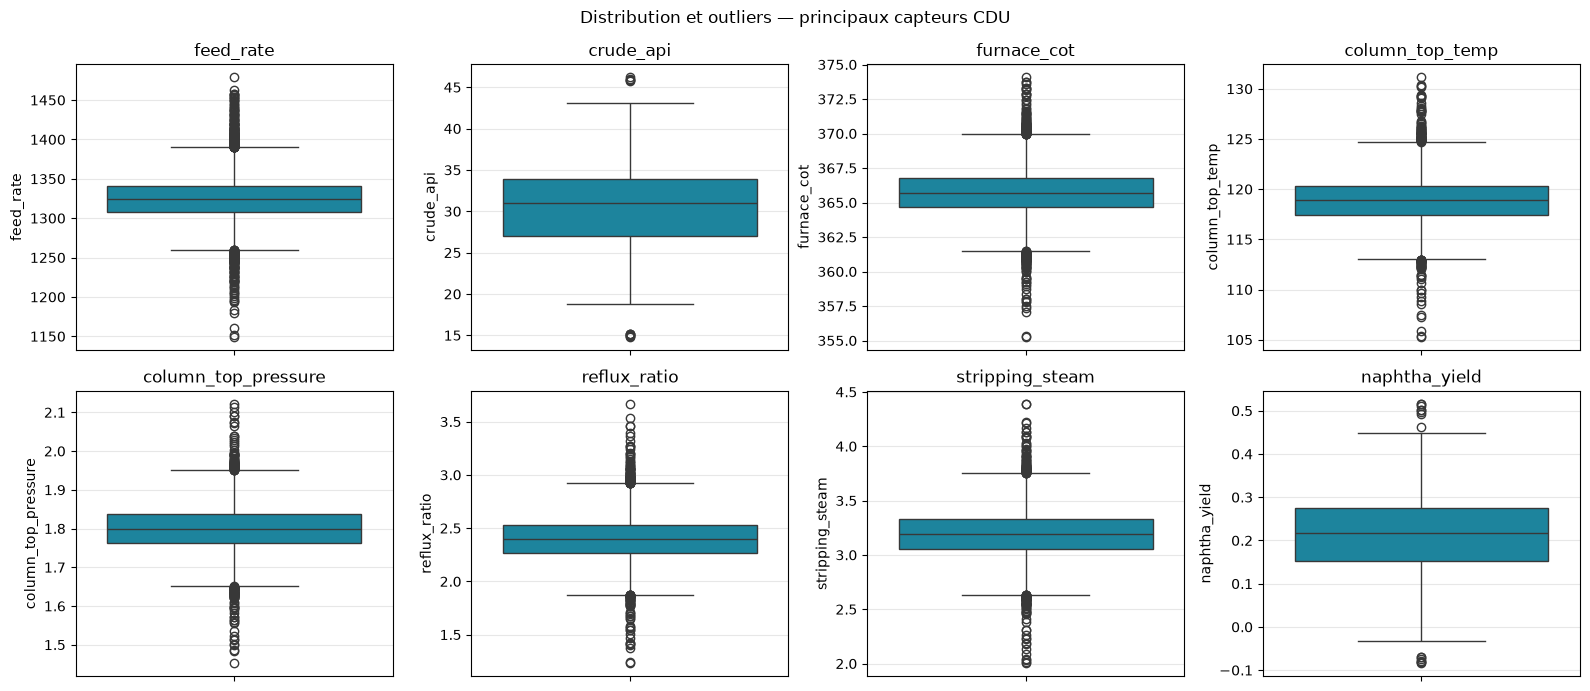

In [4]:
numeric_cols = [c for c in cdu.columns if c != "crude_type"]
outlier_summary = {}
for col in numeric_cols:
    q1, q3 = cdu[col].quantile(0.25), cdu[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
    n_iqr = ((cdu[col] < lo) | (cdu[col] > hi)).sum()
    z = (cdu[col] - cdu[col].mean()) / cdu[col].std()
    n_z = (z.abs() > 4).sum()
    outlier_summary[col] = {"n_outliers_IQR(k=3)": n_iqr, "n_outliers_zscore(>4)": n_z}

display(pd.DataFrame(outlier_summary).T)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), numeric_cols[:8]):
    sns.boxplot(y=cdu[col], ax=ax, color="#0891b2")
    ax.set_title(col)
fig.suptitle("Distribution et outliers — principaux capteurs CDU")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_outliers_boxplots.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (3. Outliers)** — Les capteurs montrent un nombre d'outliers cohérent avec le
taux d'injection (~0.3 % des lignes, magnitude ~4σ). Ces valeurs seront traitées par
winsorisation (clipping IQR) dans le préprocessing, sans les supprimer (préservation de la
taille des séries temporelles).

## 4. Séries temporelles clés

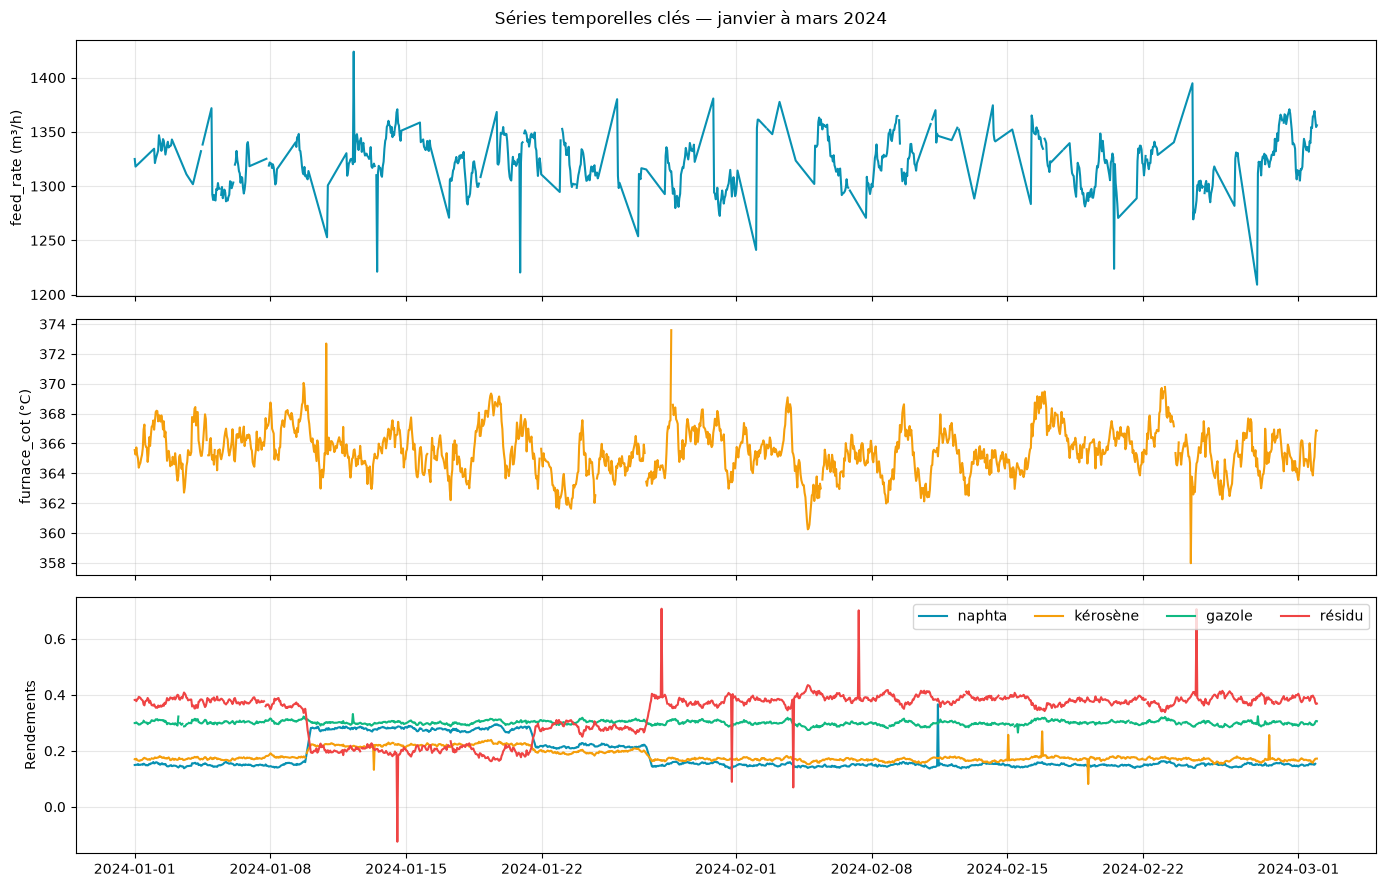

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
window = slice("2024-01-01", "2024-03-01")
axes[0].plot(cdu.loc[window].index, cdu.loc[window, "feed_rate"], color="#0891b2")
axes[0].set_ylabel("feed_rate (m³/h)")
axes[1].plot(cdu.loc[window].index, cdu.loc[window, "furnace_cot"], color="#f59e0b")
axes[1].set_ylabel("furnace_cot (°C)")
axes[2].plot(cdu.loc[window].index, cdu.loc[window, ["naphtha_yield", "kerosene_yield", "gasoil_yield", "residue_yield"]])
axes[2].set_ylabel("Rendements")
axes[2].legend(["naphta", "kérosène", "gazole", "résidu"], ncol=4, loc="upper right")
fig.suptitle("Séries temporelles clés — janvier à mars 2024")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_series_temporelles_cles.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (4. Séries temporelles)** — Le débit de charge présente des rampes réalistes,
le COT four oscille autour du point de consigne avec un contrôleur imparfait, et les
rendements suivent des variations lentes cohérentes avec les changements de brut et l'effet COT.

## 5. Effets des changements de brut

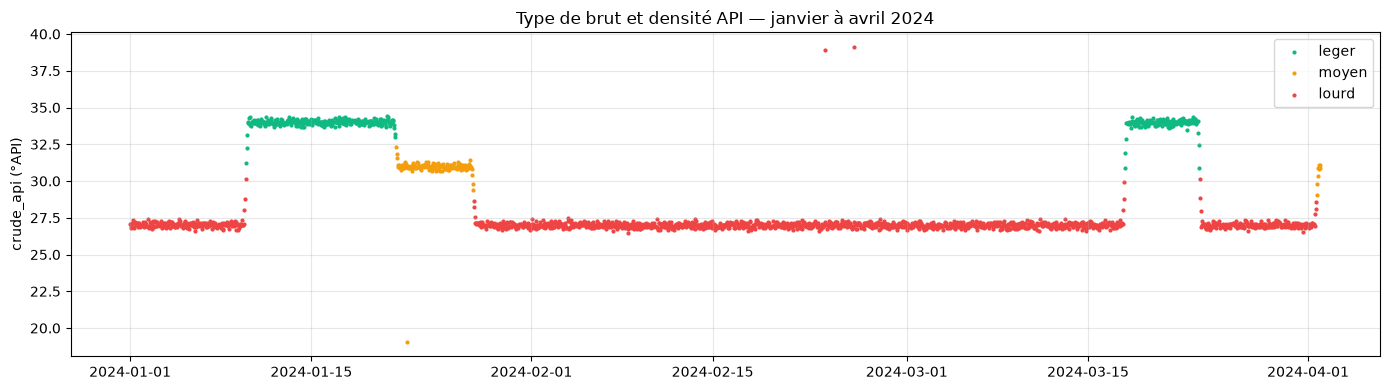

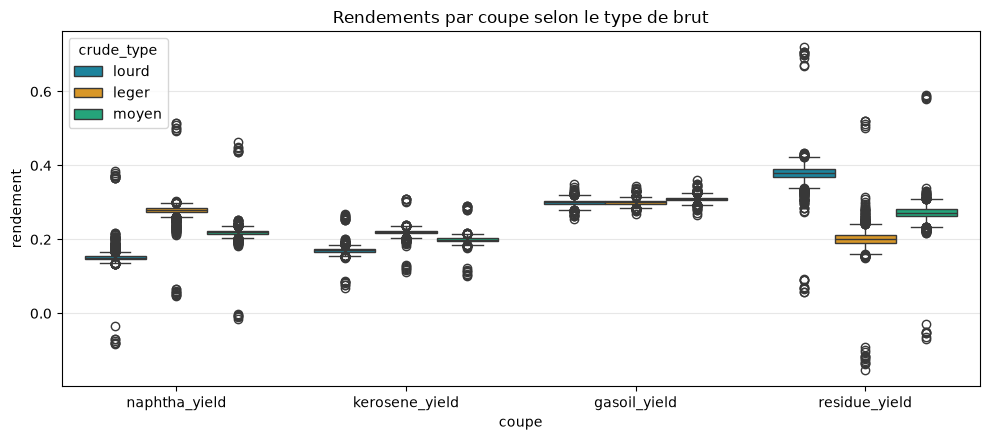

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
window = slice("2024-01-01", "2024-04-01")
sub = cdu.loc[window]
for crude, color in zip(["leger", "moyen", "lourd"], ["#10b981", "#f59e0b", "#ef4444"]):
    mask = sub["crude_type"] == crude
    ax.scatter(sub.index[mask], sub.loc[mask, "crude_api"], s=4, color=color, label=crude)
ax.set_ylabel("crude_api (°API)")
ax.set_title("Type de brut et densité API — janvier à avril 2024")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "01_changements_brut.png", dpi=130, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
cdu_yield_long = cdu.melt(id_vars="crude_type",
                          value_vars=["naphtha_yield", "kerosene_yield", "gasoil_yield", "residue_yield"],
                          var_name="coupe", value_name="rendement")
sns.boxplot(data=cdu_yield_long, x="coupe", y="rendement", hue="crude_type", ax=ax)
ax.set_title("Rendements par coupe selon le type de brut")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_rendements_par_brut.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (5. Effets des changements de brut)** — Le brut lourd (API ~27) donne davantage
de résidu et moins de naphta que le brut léger (API ~34), conformément à la courbe TBP
attendue. Les transitions entre bruts sont lissées sur quelques heures (pas de saut brutal).

## 6. Corrélations

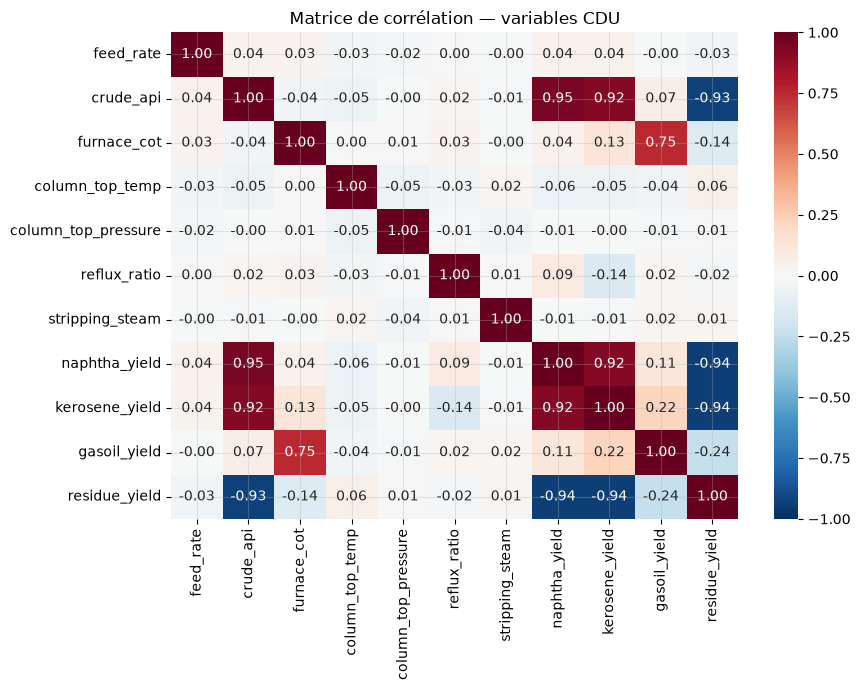

In [7]:
corr_cols = ["feed_rate", "crude_api", "furnace_cot", "column_top_temp", "column_top_pressure",
             "reflux_ratio", "stripping_steam", "naphtha_yield", "kerosene_yield",
             "gasoil_yield", "residue_yield"]
corr = cdu[corr_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Matrice de corrélation — variables CDU")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_correlations.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (6. Corrélations)** — `furnace_cot` est positivement corrélé aux distillats
légers et négativement au résidu, confirmant l'effet non linéaire codé dans le générateur.
Le `reflux_ratio` influence surtout la netteté naphta/kérosène.

## 7. Distributions des rendements par brut

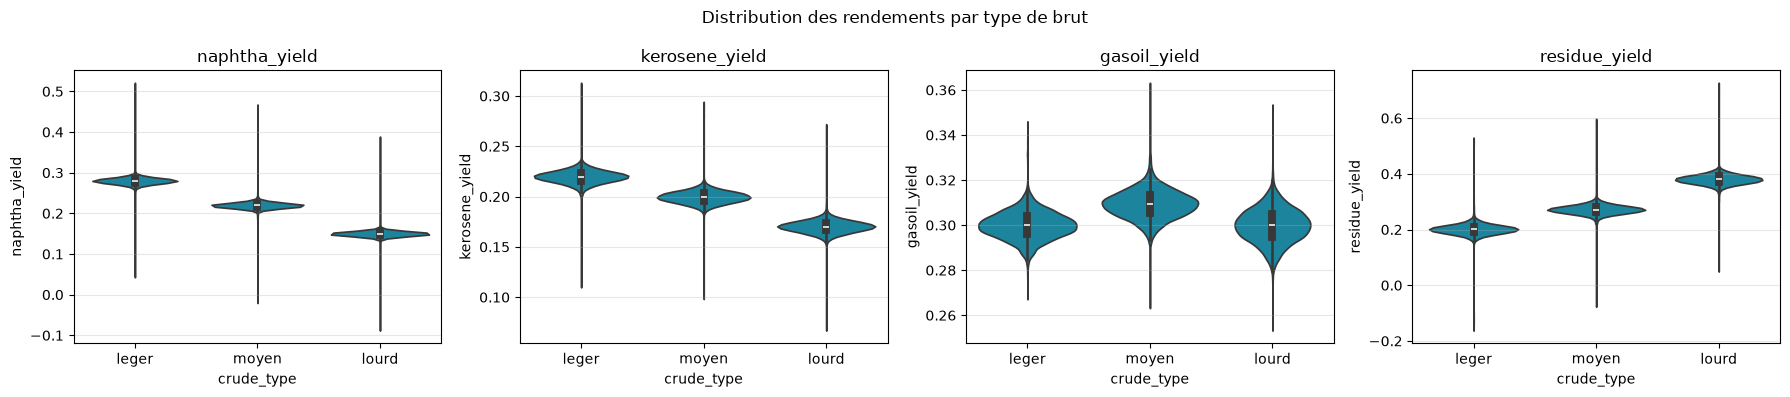

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ["naphtha_yield", "kerosene_yield", "gasoil_yield", "residue_yield"]):
    sns.violinplot(data=cdu, x="crude_type", y=col, ax=ax, order=["leger", "moyen", "lourd"])
    ax.set_title(col)
fig.suptitle("Distribution des rendements par type de brut")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_distributions_rendements.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (7. Distributions)** — Les distributions se décalent clairement selon le brut,
avec un chevauchement partiel dû aux effets COT/reflux qui modulent les rendements
indépendamment du brut utilisé — c'est précisément ce que les modèles séquentiels devront apprendre.

## 8. Cycle de fouling (encrassement)

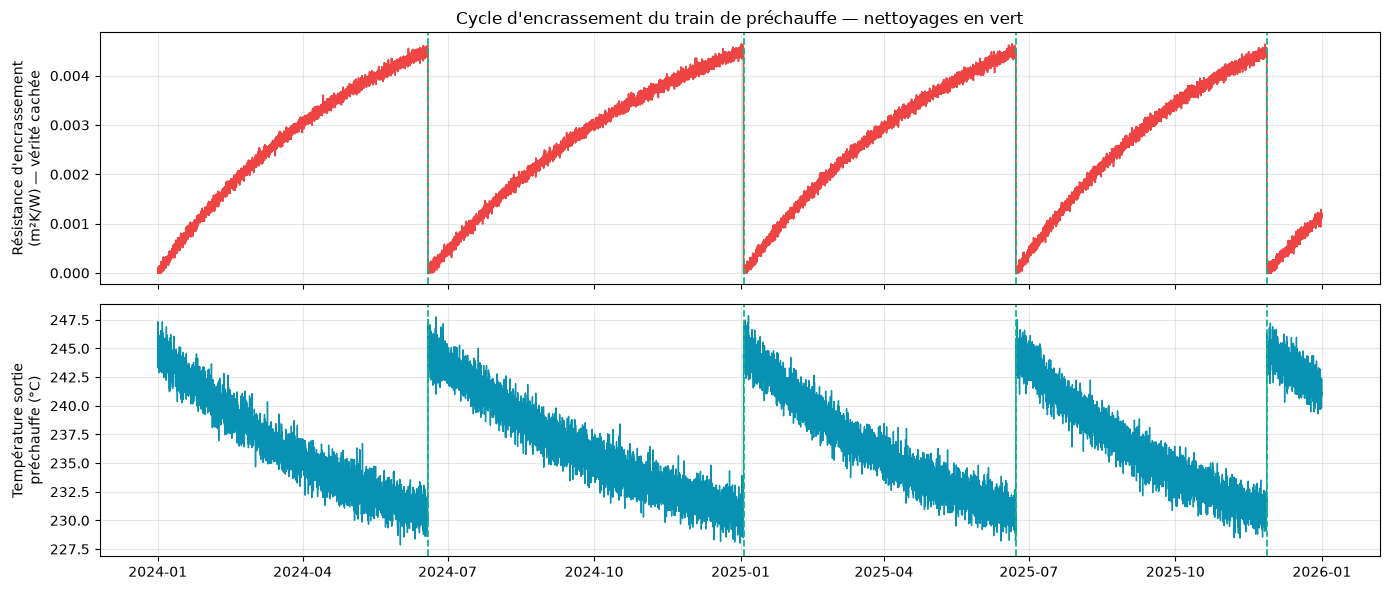

4 nettoyages sur la période de 2 ans :
 - 2024-06-18 16:00:00
 - 2025-01-02 21:00:00
 - 2025-06-22 21:00:00
 - 2025-11-27 10:00:00


In [9]:
cleaning_times = energy.index[energy["is_cleaning_event"] == 1]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(energy.index, energy["fouling_resistance"], color="#ef4444", linewidth=1.2)
for t in cleaning_times:
    axes[0].axvline(t, color="#10b981", linestyle="--", linewidth=1.3)
axes[0].set_ylabel("Résistance d'encrassement\n(m²K/W) — vérité cachée")
axes[0].set_title("Cycle d'encrassement du train de préchauffe — nettoyages en vert")

axes[1].plot(energy.index, energy["preheat_outlet_temp"], color="#0891b2", linewidth=1.0)
for t in cleaning_times:
    axes[1].axvline(t, color="#10b981", linestyle="--", linewidth=1.3)
axes[1].set_ylabel("Température sortie\npréchauffe (°C)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_cycle_fouling.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"{len(cleaning_times)} nettoyages sur la période de 2 ans :")
for t in cleaning_times:
    print(" -", t)

**Conclusion (8. Cycle de fouling)** — La résistance d'encrassement croît de façon
asymptotique (Ebert-Panchal simplifié) et retombe à ~0 lors de chaque nettoyage
(4 événements sur 2 ans, cohérent avec la spécification "4-5 nettoyages"). La température
de sortie du train de préchauffe baisse en miroir, confirmant son rôle de proxy observable
pour un indice de fouling — c'est la base de l'approche par résidus du notebook 04.

## 9. Décomposition STL

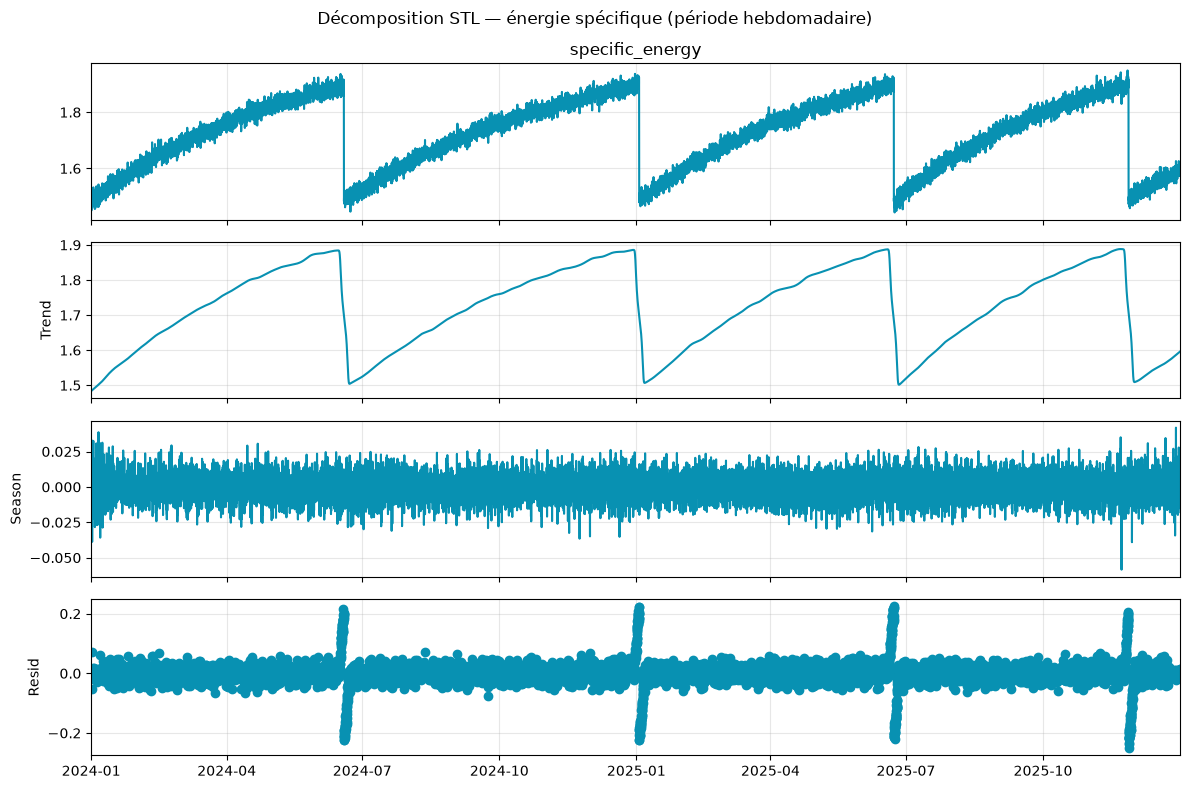

In [10]:
stl_series = energy["specific_energy"].asfreq("h").interpolate()
stl = STL(stl_series, period=24 * 7, robust=True).fit()

fig = stl.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Décomposition STL — énergie spécifique (période hebdomadaire)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_stl_decomposition.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (9. STL)** — La composante tendance de l'énergie spécifique suit la croissance
progressive du fouling entre deux nettoyages ; la composante saisonnière hebdomadaire est
faible (le procédé tourne en continu 24/7 sans cycle hebdomadaire marqué), ce qui est
physiquement attendu pour une unité de raffinage continue.

## 10. Autocorrélation (ACF / PACF)

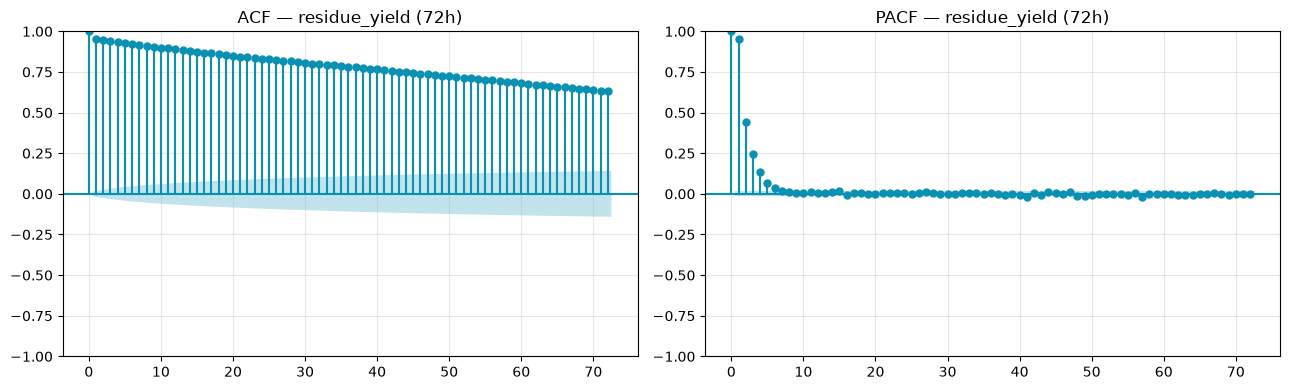

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(cdu["residue_yield"].dropna(), lags=72, ax=axes[0])
axes[0].set_title("ACF — residue_yield (72h)")
plot_pacf(cdu["residue_yield"].dropna(), lags=72, ax=axes[1], method="ywm")
axes[1].set_title("PACF — residue_yield (72h)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_acf_pacf.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (10. ACF/PACF)** — Une autocorrélation forte et une décroissance lente sont
visibles sur plusieurs dizaines d'heures, ce qui justifie le choix d'une **fenêtre de 24 h**
pour la prédiction des rendements (notebook 03) : l'information pertinente pour prédire t+1
est bien contenue dans l'historique récent.

## Conclusion générale

Les données synthétiques reproduisent fidèlement les dynamiques attendues d'une unité CDU :
effets de brut, effets COT/reflux sur les rendements, cycle d'encrassement asymptotique avec
nettoyages périodiques, et autocorrélation temporelle exploitable par des modèles séquentiels.
Le notebook 02 traite les défauts volontairement injectés (valeurs manquantes, outliers,
dérive capteur) avant modélisation.